### Import Library and data

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/tourism_arrivals_clean.csv"
)

### Line chart

In [104]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

yearly

,Year,Tourist_Arrivals
0,2018,2333796.0
1,2019,1913702.0
2,2020,507699.0
3,2021,194495.0
4,2022,719978.0
5,2023,1487303.0
6,2024,2053465.0
7,2025,2362521.0


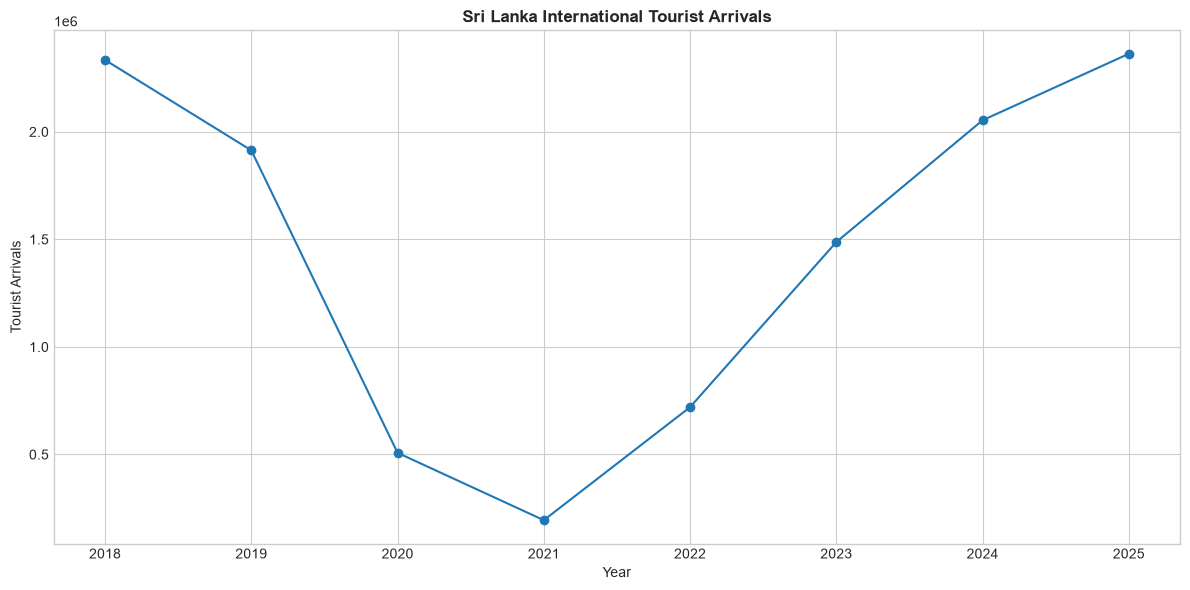

In [105]:
plt.figure(figsize=(12, 6))

plt.plot(
    yearly["Year"],
    yearly["Tourist_Arrivals"],
    marker="o"
)

plt.title(
    "Sri Lanka International Tourist Arrivals"
)

plt.xlabel("Year")
plt.ylabel("Tourist Arrivals")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/yearly_tourist_arrivals.png",
    dpi=300
)

plt.show()

In [106]:
df.columns

Index(['Year', 'Country', 'Month', 'Tourist_Arrivals', 'Month_Number', 'Date'], dtype='str')

### Year over Year Growth Analysis

In [107]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

yearly["YoY_Growth_%"] = (
    yearly["Tourist_Arrivals"]
    .pct_change()
    * 100
)

yearly

,Year,Tourist_Arrivals,YoY_Growth_%
0,2018,2333796.0,NaN
1,2019,1913702.0,-18.000459
2,2020,507699.0,-73.470321
3,2021,194495.0,-61.690884
4,2022,719978.0,270.178154
5,2023,1487303.0,106.576173
6,2024,2053465.0,38.066352
7,2025,2362521.0,15.050463


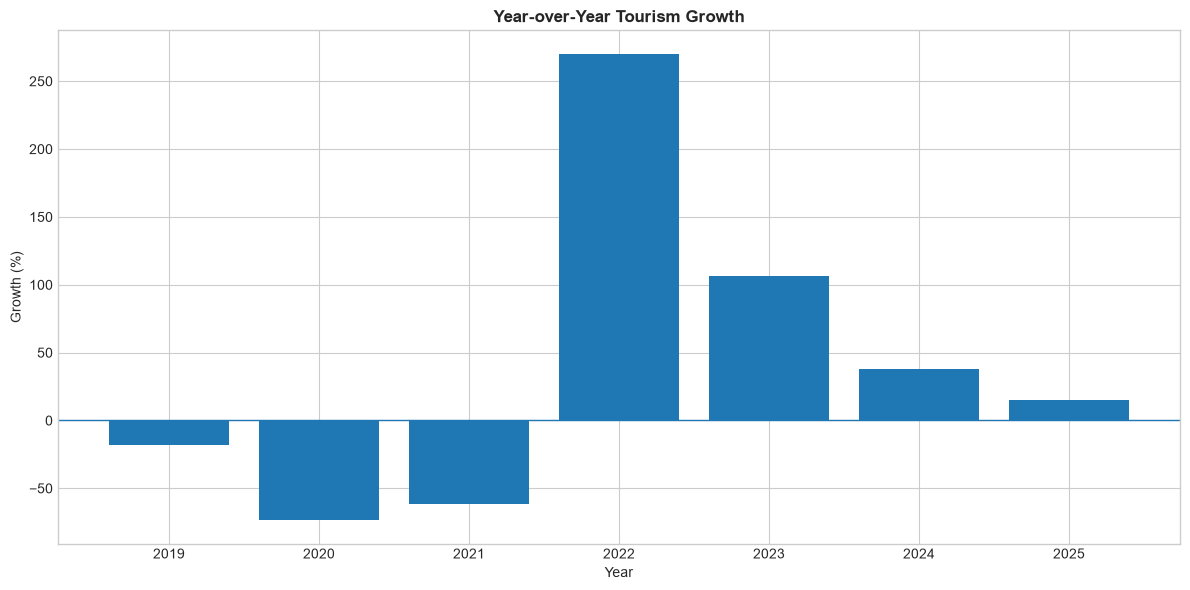

In [178]:
yearly_growth = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

yearly_growth["YoY_Growth_%"] = (
    yearly_growth["Tourist_Arrivals"]
    .pct_change()
    * 100
)

plt.figure(figsize=(12, 6))

plt.bar(
    yearly_growth["Year"],
    yearly_growth["YoY_Growth_%"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Year-over-Year Tourism Growth"
)

plt.xlabel("Year")
plt.ylabel("Growth (%)")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/yearly_growth.png",
    dpi=300
)

plt.show()

### Monthly_and_Seasonality Analysis

KeyError: 'YoY_Growth_%'

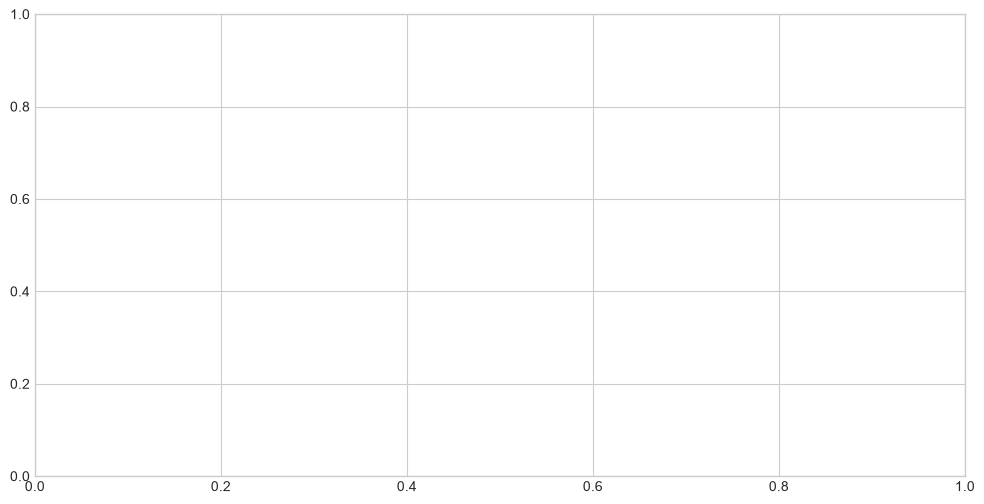

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))



bars = ax.bar(
    yearly["Year"].astype(str),
    yearly["YoY_Growth_%"].fillna(0),
    color=colors,
    width=0.6,
    edgecolor="black",
    linewidth=0.8
)

ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)

# Data labels on bars
for bar in bars:
    height = bar.get_height()
    va = "bottom" if height >= 0 else "top"
    offset = 4 if height >= 0 else -14
    if not np.isnan(height) and height != 0:
        ax.annotate(
            f"{height:+.1f}%",
            (bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va=va,
            fontsize=9.5,
            fontweight="bold"
        )

ax.set_title("Year-over-Year (YoY) Tourism Growth Rate (%)", pad=15)
ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("YoY Growth (%)", fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.5, axis="y")

plt.tight_layout()
plt.show()

### Monthly and Seasonality Analysis

In [109]:
monthly = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values("Month_Number")
)

monthly

,Month_Number,Month,Tourist_Arrivals
0,1,January,1359164.0
1,2,February,1361234.0
2,3,March,1224134.0
3,4,April,843525.0
4,5,May,527328.0
5,6,June,596469.0
6,7,July,914345.0
7,8,August,885995.0
8,9,September,694060.0
9,10,October,746962.0


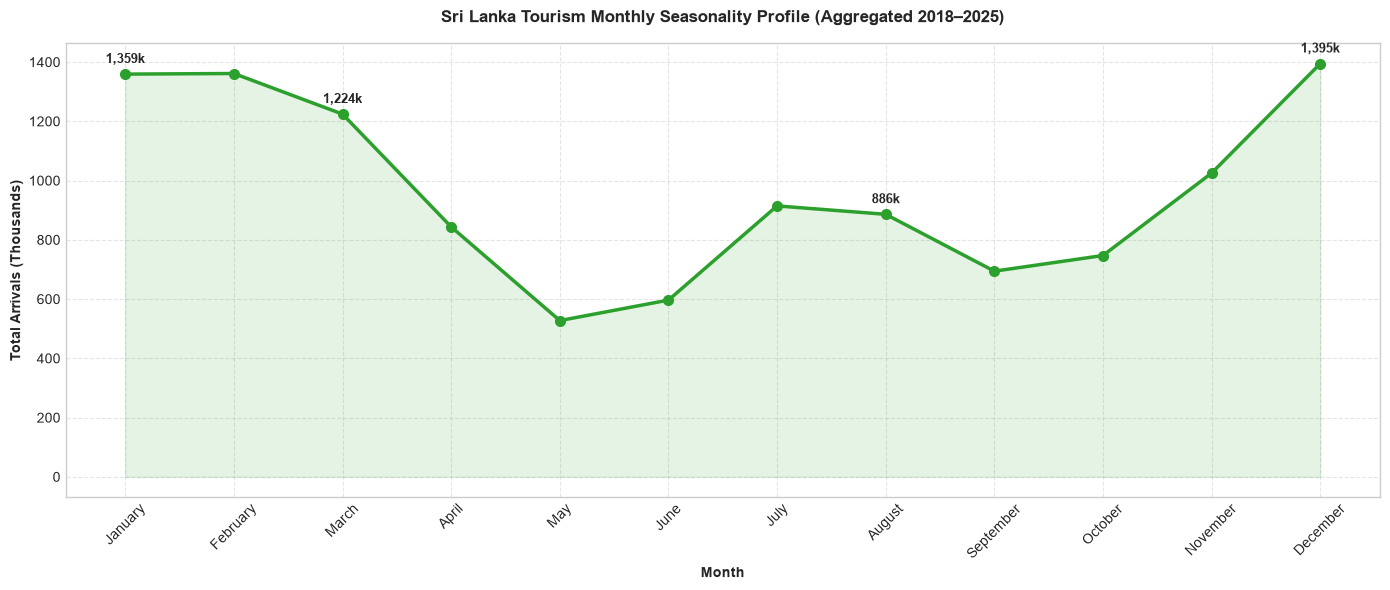

In [110]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly["Month"],
    monthly["Tourist_Arrivals"] / 1e3,
    marker="o",
    color="#2ca02c",
    linewidth=2.5,
    markersize=7
)

ax.fill_between(
    monthly["Month"],
    monthly["Tourist_Arrivals"] / 1e3,
    color="#2ca02c",
    alpha=0.12
)

# Highlight peak months (December & January)
for _, row in monthly.iterrows():
    if row["Month"] in ["December", "January", "March", "August"]:
        ax.annotate(
            f"{row['Tourist_Arrivals']/1e3:,.0f}k",
            (row["Month"], row["Tourist_Arrivals"] / 1e3),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

ax.set_title("Sri Lanka Tourism Monthly Seasonality Profile (Aggregated 2018–2025)", pad=15)
ax.set_xlabel("Month", fontweight="bold")
ax.set_ylabel("Total Arrivals (Thousands)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

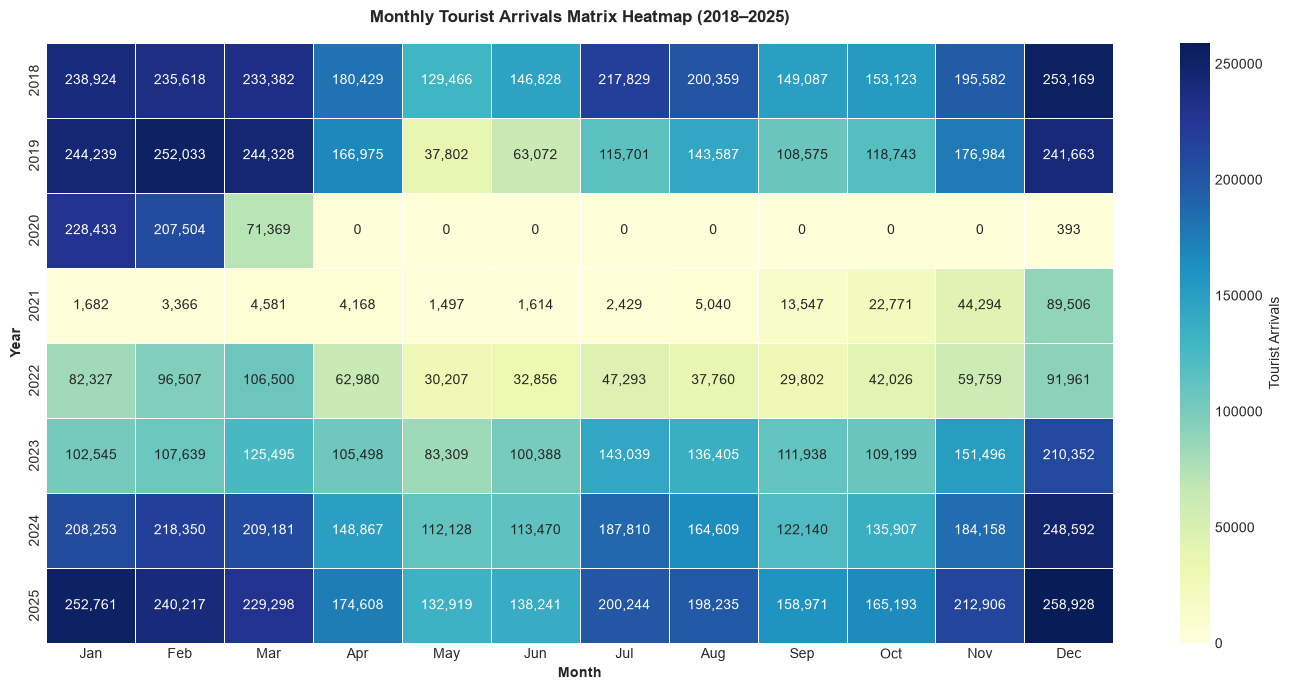

In [111]:
heatmap_data = df.pivot_table(
    index="Year",
    columns="Month_Number",
    values="Tourist_Arrivals",
    aggfunc="sum"
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=",.0f",
    cmap="YlGnBu",
    cbar_kws={"label": "Tourist Arrivals"},
    xticklabels=month_labels,
    linewidths=0.5
)

plt.title("Monthly Tourist Arrivals Matrix Heatmap (2018–2025)", pad=15)
plt.xlabel("Month", fontweight="bold")
plt.ylabel("Year", fontweight="bold")

plt.tight_layout()
plt.show()

### Country_Market_Analysis

In [112]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values(
        "Tourist_Arrivals",
        ascending=False
    )
)

country.head(20)

,Country,Tourist_Arrivals
234,India,1374333.0
416,Russian Federation,677270.0
541,United Kingdom,605891.0
531,UNITED KINGDOM,525053.0
220,INDIA,500627.0
198,Germany,442131.0
221,"INDIA, REPUBLIC OF",424887.0
182,GERMANY,338736.0
119,China,337220.0
31,Australia,297420.0


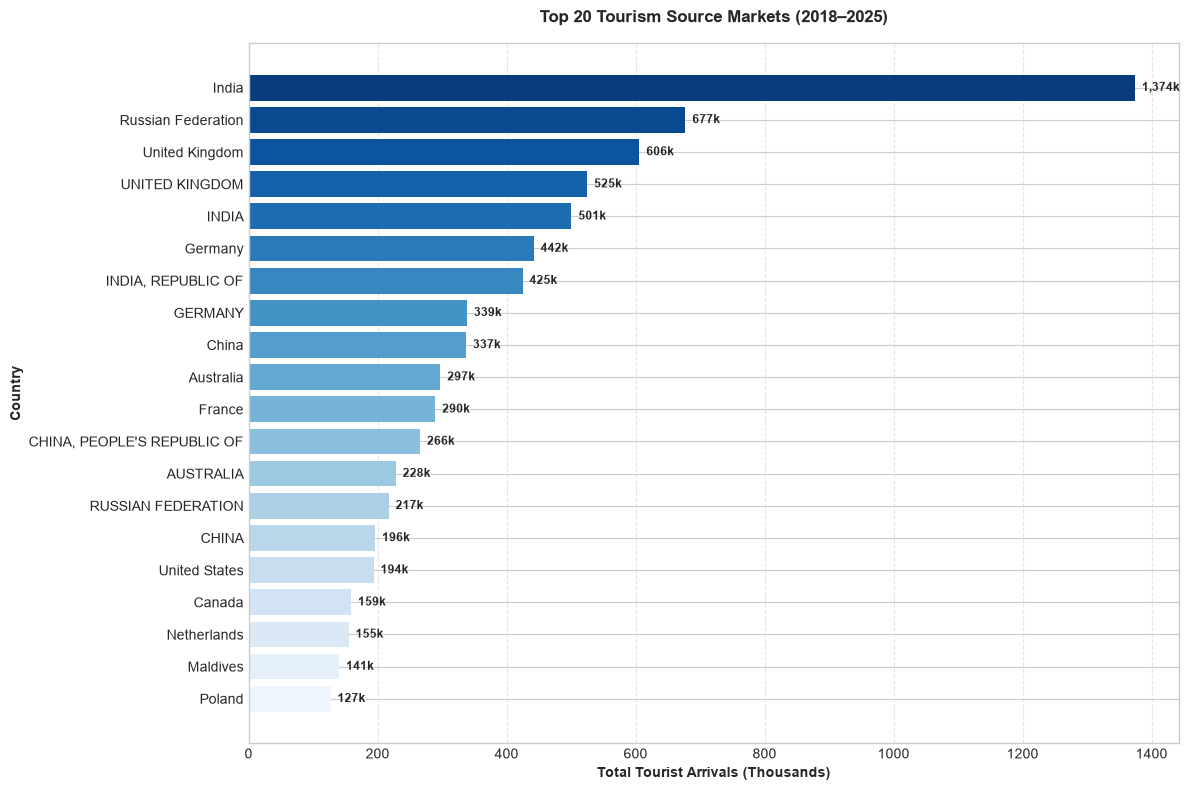

In [113]:
top20 = country.head(20).copy()

plt.figure(figsize=(12, 8))

colors = sns.color_palette("Blues_r", len(top20))
bars = plt.barh(
    top20["Country"][::-1],
    top20["Tourist_Arrivals"][::-1] / 1e3,
    color=colors[::-1],
    edgecolor="none"
)

for bar in bars:
    w = bar.get_width()
    plt.annotate(
        f"{w:,.0f}k",
        (w, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=8.5,
        fontweight="bold"
    )

plt.title("Top 20 Tourism Source Markets (2018–2025)", pad=15)
plt.xlabel("Total Tourist Arrivals (Thousands)", fontweight="bold")
plt.ylabel("Country", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5, axis="x")

plt.tight_layout()
plt.show()

### Country_Market_Share_Analysis

In [114]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

total_arrivals = country[
    "Tourist_Arrivals"
].sum()

country["Market_Share_%"] = (
    country["Tourist_Arrivals"]
    / total_arrivals
    * 100
)

country = country.sort_values(
    "Market_Share_%",
    ascending=False
)

country.head(20)

,Country,Tourist_Arrivals,Market_Share_%
234,India,1374333.0,11.875381
416,Russian Federation,677270.0,5.852177
541,United Kingdom,605891.0,5.235403
531,UNITED KINGDOM,525053.0,4.536895
220,INDIA,500627.0,4.325834
198,Germany,442131.0,3.820380
221,"INDIA, REPUBLIC OF",424887.0,3.671377
182,GERMANY,338736.0,2.926961
119,China,337220.0,2.913862
31,Australia,297420.0,2.569956


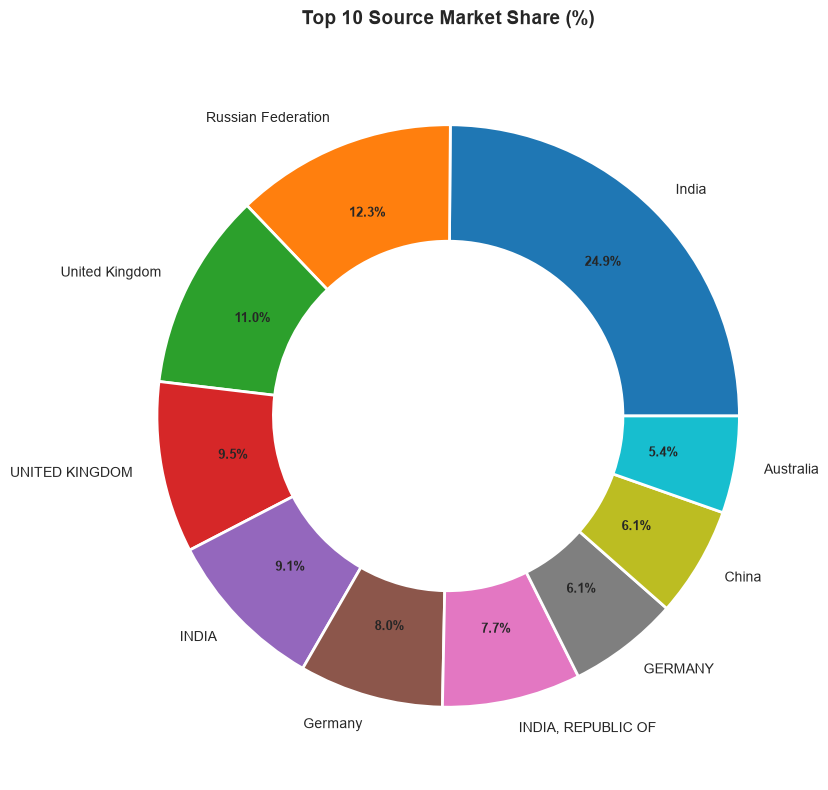

In [115]:
top10 = country.head(10).copy()

plt.figure(figsize=(9, 8))

colors = sns.color_palette("tab10", len(top10))

wedges, texts, autotexts = plt.pie(
    top10["Market_Share_%"],
    labels=top10["Country"],
    autopct="%1.1f%%",
    pctdistance=0.75,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2)
)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

plt.title("Top 10 Source Market Share (%)", pad=20, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Country_Growth_Analysis

In [116]:
country_year = (
    df.groupby(
        ["Country", "Year"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

country_year["Growth_%"] = (
    country_year
    .groupby("Country")["Tourist_Arrivals"]
    .pct_change()
    * 100
)

country_year.head()

,Country,Year,Tourist_Arrivals,Growth_%
0,A,2021,0.0,NaN
1,AFGHANISTAN,2019,473.0,NaN
2,AFGHANISTAN,2020,146.0,-69.133192
3,AFGHANISTAN,2021,15.0,-89.726027
4,"AFGHANISTAN, ISLAMIC REPUBLIC OF",2018,861.0,NaN


In [174]:
top_countries = (
    country_year
    .groupby("Country")["Tourist_Arrivals"]
    .sum()
    .nlargest(8)
    .index
)

growth_top = country_year[
    country_year["Country"].isin(top_countries)
]

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=growth_top,
    x="Year",
    y="Growth_%",
    hue="Country",
    marker="o",
    linewidth=2,
    palette="tab10"
)

plt.axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.7)

plt.title("Year-over-Year Growth Rate Across Top 8 Source Markets", pad=15)
plt.xlabel("Year", fontweight="bold")
plt.ylabel("YoY Growth Rate (%)", fontweight="bold")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, title="Top Markets")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Growth_%` for `y`. An entry with this name does not appear in `data`.

<Figure size 1400x700 with 0 Axes>

### Country_Ranking_Analysis

In [118]:
country_year = (
    df.groupby(
        ["Year", "Country"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

country_year["Rank"] = (
    country_year
    .groupby("Year")["Tourist_Arrivals"]
    .rank(
        method="min",
        ascending=False
    )
)

country_year["Rank"] = (
    country_year["Rank"]
    .astype(int)
)

country_year.head()

,Year,Country,Tourist_Arrivals,Rank
0,2018,"AFGHANISTAN, ISLAMIC REPUBLIC OF",861.0,77
1,2018,"ALBANIA, REPUBLIC OF",177.0,106
2,2018,"ALGERIA, PEOPLE'S DEMOCRATIC REPUBLIC OF",368.0,94
3,2018,"ANDORRA, PRINCIPALITY OF",53.0,131
4,2018,"ANGOLA, REPUBLIC OF",9.0,173


In [119]:
top10_each_year = country_year[
    country_year["Rank"] <= 10
].sort_values(
    ["Year", "Rank"]
)

top10_each_year

,Year,Country,Tourist_Arrivals,Rank
74,2018,"INDIA, REPUBLIC OF",424887.0,1
35,2018,"CHINA, PEOPLE'S REPUBLIC OF",265965.0,2
186,2018,UNITED KINGDOM,254176.0,3
62,2018,GERMANY,156888.0,4
8,2018,AUSTRALIA,110928.0,5
...,...,...,...,...
1372,2025,Australia,109487.0,6
1423,2025,France,109041.0,7
1550,2025,United States,65973.0,8
1484,2025,Netherlands,64164.0,9


### Country_Month_Behavior_Analysis

In [120]:
country_month = (
    df.groupby(
        ["Country", "Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

country_month.head()

,Country,Month_Number,Month,Tourist_Arrivals
0,A,1,January,0.0
1,A,2,February,0.0
2,A,3,March,0.0
3,A,4,April,0.0
4,A,5,May,0.0


In [121]:
selected_country = "India"

india = country_month[
    country_month["Country"].str.upper()
    == selected_country.upper()
]

india

,Country,Month_Number,Month,Tourist_Arrivals
2640,INDIA,1,January,81514.0
2641,INDIA,2,February,67674.0
2642,INDIA,3,March,47595.0
2643,INDIA,4,April,24227.0
2644,INDIA,5,May,11285.0
2645,INDIA,6,June,15053.0
2646,INDIA,7,July,18317.0
2647,INDIA,8,August,37973.0
2648,INDIA,9,September,37445.0
2649,INDIA,10,October,41623.0


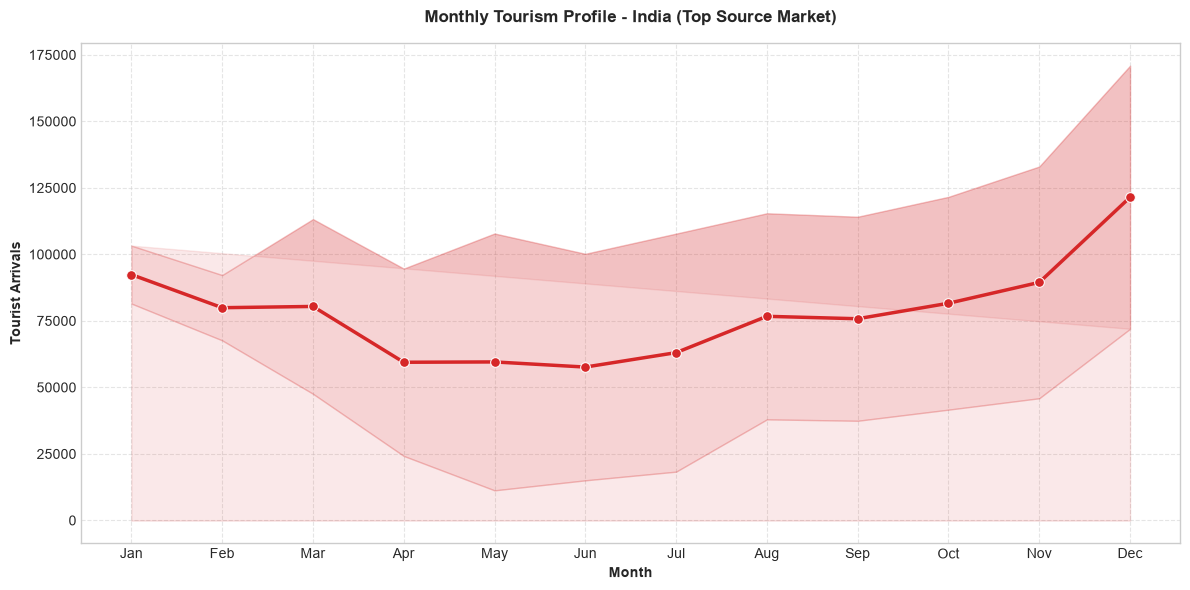

In [122]:
Month = (
    df.sort_values("Month_Number")["Month"]
    .drop_duplicates()
    .tolist()
)

month_abbr = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=india,
    x="Month_Number",
    y="Tourist_Arrivals",
    marker="o",
    color="#d62728",
    linewidth=2.5,
    markersize=7
)

plt.fill_between(
    india["Month_Number"],
    india["Tourist_Arrivals"],
    color="#d62728",
    alpha=0.1
)

plt.xticks(
    range(1, 13),
    month_abbr,
    rotation=0
)

plt.title(f"Monthly Tourism Profile - {selected_country} (Top Source Market)", pad=15)
plt.xlabel("Month", fontweight="bold")
plt.ylabel("Tourist Arrivals", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Regional Market Analysis

In [123]:
import country_converter as coco

In [124]:
df["Continent"] = coco.convert(
    df["Country"],
    to="continent",
    not_found=None
)

df[
    ["Country", "Continent"]
].drop_duplicates().head(20)

NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
NETHERLAND ANTILLES not found in regex
SOLOMAN ISLANDS not found in regex
Country not found in regex
KOSOVAR not found in regex
Country not found in regex
KOSOVAR not found in regex
Coun

,Country,Continent
0,"AFGHANISTAN, ISLAMIC REPUBLIC OF",Asia
1,"ALBANIA, REPUBLIC OF",Europe
2,"ALGERIA, PEOPLE'S DEMOCRATIC REPUBLIC OF",Africa
3,"ANDORRA, PRINCIPALITY OF",Europe
4,"ANGOLA, REPUBLIC OF",Africa
5,ANTIGUA & BARBUDA,America
6,ARGENTINA,America
7,"ARMENIA, REPUBLIC OF",Asia
8,AUSTRALIA,Oceania
9,AUSTRIA,Europe


In [125]:
continent_summary = (
    df.groupby("Continent")["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values(
        "Tourist_Arrivals",
        ascending=False
    )
)

continent_summary

,Continent,Tourist_Arrivals
14,Europe,5431692.0
4,Asia,4761506.0
2,America,683844.0
29,Oceania,592095.0
1,Africa,103639.0
22,Kosovar,96.0
21,KOSOVAR,53.0
8,Cote d'lvoire,15.0
35,SOLOMAN ISLANDS,13.0
27,Netherlands Antilles,2.0


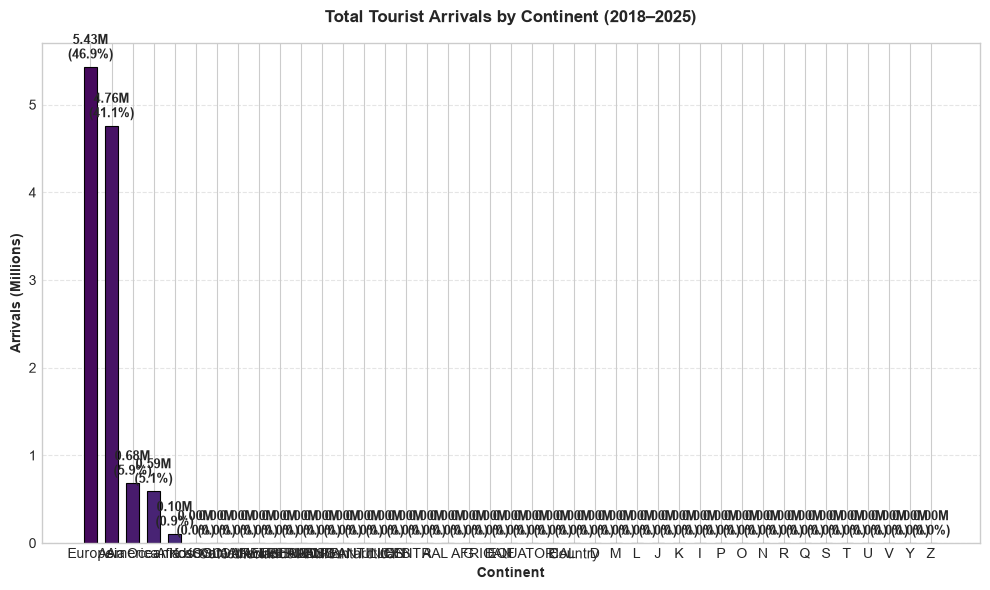

In [126]:
plt.figure(figsize=(10, 6))

colors = sns.color_palette("viridis", len(continent_summary))

bars = plt.bar(
    continent_summary["Continent"],
    continent_summary["Tourist_Arrivals"] / 1e6,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.6
)

for bar in bars:
    h = bar.get_height()
    pct = (h / (continent_summary["Tourist_Arrivals"].sum() / 1e6)) * 100
    plt.annotate(
        f"{h:.2f}M\n({pct:.1f}%)",
        (bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Total Tourist Arrivals by Continent (2018–2025)", pad=15)
plt.xlabel("Continent", fontweight="bold")
plt.ylabel("Arrivals (Millions)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5, axis="y")

plt.tight_layout()
plt.show()

### Tourism_Concentration_Pareto_Analysis

In [127]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values(
        "Tourist_Arrivals",
        ascending=False
    )
)

country["Cumulative_Arrivals"] = (
    country["Tourist_Arrivals"].cumsum()
)

country["Cumulative_%"] = (
    country["Cumulative_Arrivals"]
    / country["Tourist_Arrivals"].sum()
    * 100
)

country.head(20)

,Country,Tourist_Arrivals,Cumulative_Arrivals,Cumulative_%
234,India,1374333.0,1374333.0,11.875381
416,Russian Federation,677270.0,2051603.0,17.727558
541,United Kingdom,605891.0,2657494.0,22.962960
531,UNITED KINGDOM,525053.0,3182547.0,27.499855
220,INDIA,500627.0,3683174.0,31.825690
198,Germany,442131.0,4125305.0,35.646069
221,"INDIA, REPUBLIC OF",424887.0,4550192.0,39.317447
182,GERMANY,338736.0,4888928.0,42.244408
119,China,337220.0,5226148.0,45.158269
31,Australia,297420.0,5523568.0,47.728226


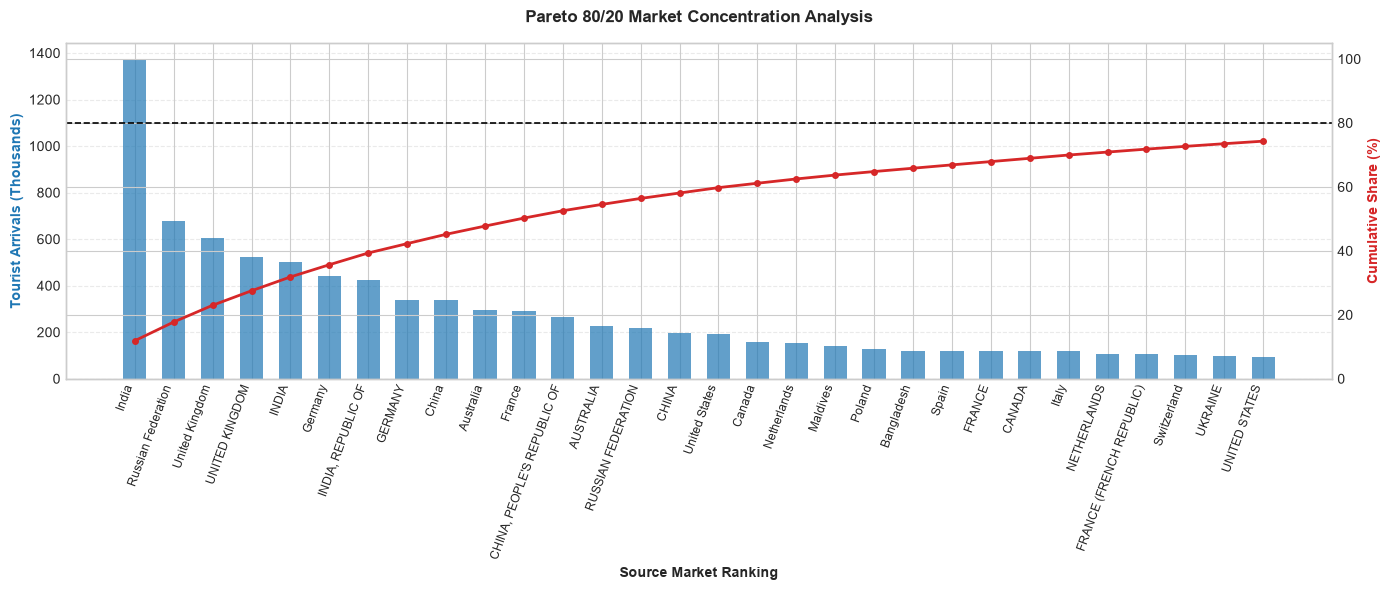

In [128]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot top 30 countries for clarity
country_top30 = country.head(30).reset_index(drop=True)

ax1.bar(
    range(len(country_top30)),
    country_top30["Tourist_Arrivals"] / 1e3,
    color="#1f77b4",
    alpha=0.7,
    width=0.6,
    label="Arrivals"
)
ax1.set_ylabel("Tourist Arrivals (Thousands)", fontweight="bold", color="#1f77b4")
ax1.set_xlabel("Source Market Ranking", fontweight="bold")
ax1.set_xticks(range(len(country_top30)))
ax1.set_xticklabels(country_top30["Country"], rotation=70, ha="right", fontsize=8.5)

ax2 = ax1.twinx()
ax2.plot(
    range(len(country_top30)),
    country_top30["Cumulative_%"],
    color="#d62728",
    marker="o",
    linewidth=2,
    markersize=4,
    label="Cumulative Share (%)"
)
ax2.axhline(80, color="black", linestyle="--", linewidth=1.2, label="80% Threshold")
ax2.set_ylabel("Cumulative Share (%)", fontweight="bold", color="#d62728")
ax2.set_ylim(0, 105)

plt.title("Pareto 80/20 Market Concentration Analysis", pad=15)
ax1.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

### Tourism Distribution and Outlier Analysis

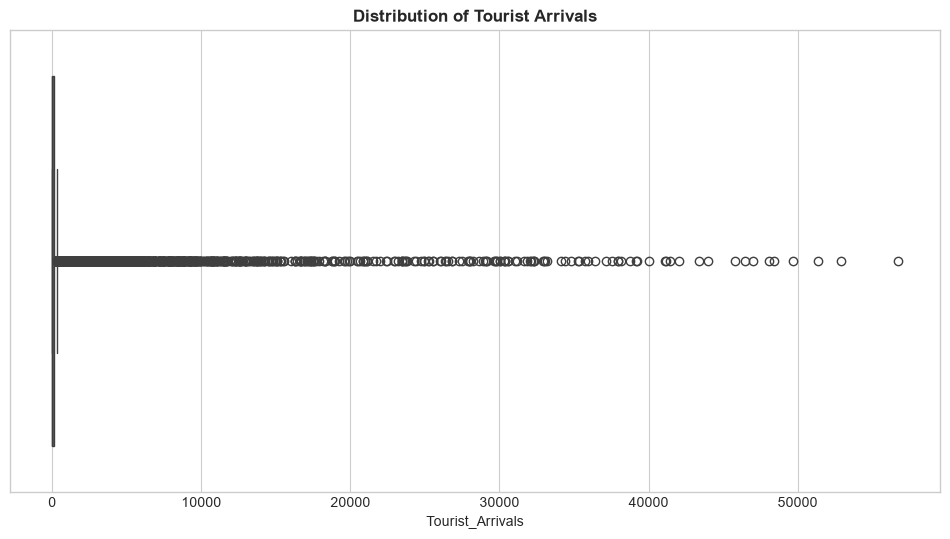

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.boxplot(
    x=df["Tourist_Arrivals"]
)

plt.title(
    "Distribution of Tourist Arrivals"
)

plt.show()

In [130]:
Q1 = df["Tourist_Arrivals"].quantile(0.25)
Q3 = df["Tourist_Arrivals"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Tourist_Arrivals"] < lower)
    |
    (df["Tourist_Arrivals"] > upper)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Outliers:", len(outliers))

Q1: 0.0
Q3: 116.0
IQR: 116.0
Outliers: 3397


### Pre Crisis vs Post Crisis Analysis

In [131]:
df["Period"] = np.select(
    [
        df["Year"] <= 2019,
        df["Year"].isin([2020, 2021]),
        df["Year"] >= 2022
    ],
    [
        "Pre-Crisis",
        "Crisis",
        "Post-Crisis"
    ],
    default="Other"
)

period_summary = (
    df.groupby("Period")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

period_summary

,Period,Tourist_Arrivals
0,Crisis,702194.0
1,Post-Crisis,6623267.0
2,Pre-Crisis,4247498.0


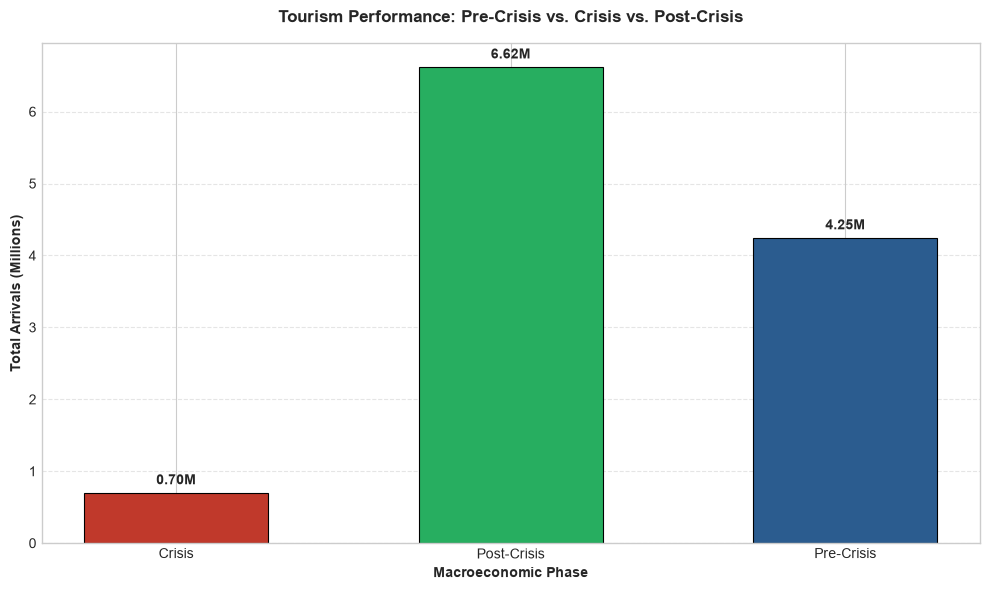

In [132]:
plt.figure(figsize=(10, 6))

period_colors = {
    "Pre-Crisis": "#2b5c8f",
    "Crisis": "#c0392b",
    "Post-Crisis": "#27ae60"
}

colors = [period_colors.get(p, "gray") for p in period_summary["Period"]]

bars = plt.bar(
    period_summary["Period"],
    period_summary["Tourist_Arrivals"] / 1e6,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.55
)

for bar in bars:
    h = bar.get_height()
    plt.annotate(
        f"{h:.2f}M",
        (bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Tourism Performance: Pre-Crisis vs. Crisis vs. Post-Crisis", pad=15)
plt.xlabel("Macroeconomic Phase", fontweight="bold")
plt.ylabel("Total Arrivals (Millions)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5, axis="y")

plt.tight_layout()
plt.show()

### Tourism_Recovery_Analysis

In [133]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

baseline = yearly.loc[
    yearly["Year"] == 2019,
    "Tourist_Arrivals"
].iloc[0]

yearly["Recovery_Index"] = (
    yearly["Tourist_Arrivals"]
    / baseline
    * 100
)

yearly

,Year,Tourist_Arrivals,Recovery_Index
0,2018,2333796.0,121.951903
1,2019,1913702.0,100.000000
2,2020,507699.0,26.529679
3,2021,194495.0,10.163286
4,2022,719978.0,37.622263
5,2023,1487303.0,77.718631
6,2024,2053465.0,107.303279
7,2025,2362521.0,123.452920


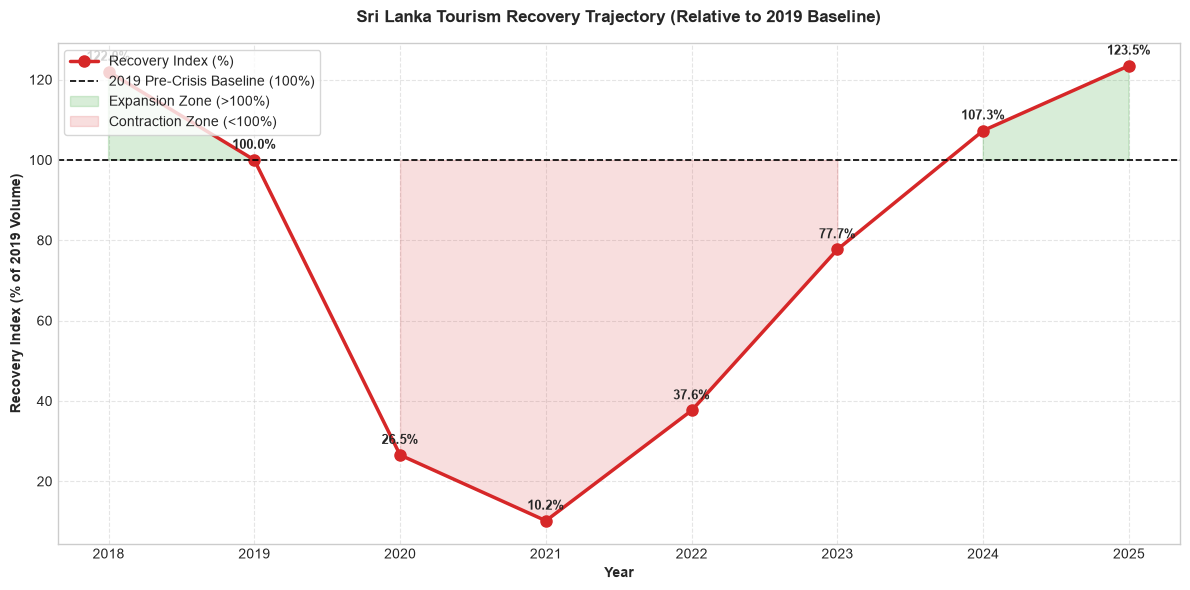

In [134]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    yearly["Year"],
    yearly["Recovery_Index"],
    marker="o",
    color="#d62728",
    linewidth=2.5,
    markersize=8,
    label="Recovery Index (%)"
)

ax.axhline(
    100,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="2019 Pre-Crisis Baseline (100%)"
)

ax.fill_between(
    yearly["Year"],
    100,
    yearly["Recovery_Index"],
    where=(yearly["Recovery_Index"] >= 100),
    color="#2ca02c",
    alpha=0.18,
    label="Expansion Zone (>100%)"
)

ax.fill_between(
    yearly["Year"],
    100,
    yearly["Recovery_Index"],
    where=(yearly["Recovery_Index"] < 100),
    color="#d62728",
    alpha=0.15,
    label="Contraction Zone (<100%)"
)

for _, row in yearly.iterrows():
    ax.annotate(
        f"{row['Recovery_Index']:.1f}%",
        (row["Year"], row["Recovery_Index"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9.5,
        fontweight="bold"
    )

ax.set_title("Sri Lanka Tourism Recovery Trajectory (Relative to 2019 Baseline)", pad=15)
ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("Recovery Index (% of 2019 Volume)", fontweight="bold")
ax.legend(loc="upper left", frameon=True)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Long Term CAGR Analysis

In [135]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

start_year = yearly["Year"].min()
end_year = yearly["Year"].max()

start_value = yearly.loc[
    yearly["Year"] == start_year,
    "Tourist_Arrivals"
].iloc[0]

end_value = yearly.loc[
    yearly["Year"] == end_year,
    "Tourist_Arrivals"
].iloc[0]

years = end_year - start_year

CAGR = (
    (end_value / start_value)
    ** (1 / years)
    - 1
) * 100

print(
    f"CAGR from {start_year} to {end_year}: "
    f"{CAGR:.2f}%"
)

CAGR from 2018 to 2025: 0.17%


### Tourism_Market_Segmentation

In [136]:
country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

q1 = country["Tourist_Arrivals"].quantile(0.25)
q2 = country["Tourist_Arrivals"].quantile(0.50)
q3 = country["Tourist_Arrivals"].quantile(0.75)

In [137]:
def classify_market(value):
    
    if value >= q3:
        return "High Volume"
    
    elif value >= q2:
        return "Medium-High Volume"
    
    elif value >= q1:
        return "Medium-Low Volume"
    
    else:
        return "Low Volume"


country["Market_Segment"] = (
    country["Tourist_Arrivals"]
    .apply(classify_market)
)

country.head()

,Country,Tourist_Arrivals,Market_Segment
0,A,0.0,Low Volume
1,AFGHANISTAN,634.0,Medium-High Volume
2,"AFGHANISTAN, ISLAMIC REPUBLIC OF",861.0,Medium-High Volume
3,ALBANIA,469.0,Medium-High Volume
4,"ALBANIA, REPUBLIC OF",177.0,Medium-Low Volume


In [138]:
segment_summary = (
    country.groupby("Market_Segment")
    ["Tourist_Arrivals"]
    .agg(
        Countries="count",
        Total_Arrivals="sum"
    )
    .reset_index()
)

segment_summary

,Market_Segment,Countries,Total_Arrivals
0,High Volume,144,11325313.0
1,Low Volume,143,1521.0
2,Medium-High Volume,143,232118.0
3,Medium-Low Volume,143,14007.0


### Top_and_Emerging_Markets

In [139]:
country_year = (
    df.groupby(
        ["Country", "Year"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

latest_year = country_year["Year"].max()

latest = country_year[
    country_year["Year"] == latest_year
].copy()

top_markets = latest.sort_values(
    "Tourist_Arrivals",
    ascending=False
).head(20)

top_markets

,Country,Year,Tourist_Arrivals
638,India,2025,531511.0
1494,United Kingdom,2025,212277.0
1151,Russian Federation,2025,186580.0
539,Germany,2025,147966.0
328,China,2025,132035.0
83,Australia,2025,109487.0
480,France,2025,109041.0
1498,United States,2025,65973.0
1008,Netherlands,2025,64164.0
172,Bangladesh,2025,59563.0


In [140]:
growth = country_year.pivot(
    index="Country",
    columns="Year",
    values="Tourist_Arrivals"
)

first_year = growth.columns.min()
last_year = growth.columns.max()

growth["Growth_%"] = (
    (growth[last_year] - growth[first_year])
    / growth[first_year].replace(0, np.nan)
    * 100
)

emerging = growth.sort_values(
    "Growth_%",
    ascending=False
)

emerging.head(20)

Year,2018,2019,2020,2021,2022,2023,2024,2025,Growth_%
Country,,,,,,,,,
TUVALU,7.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,-85.714286
A,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
AFGHANISTAN,NaN,473.0,146.0,15.0,NaN,NaN,NaN,NaN,NaN
"AFGHANISTAN, ISLAMIC REPUBLIC OF",861.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ALBANIA,NaN,369.0,97.0,3.0,NaN,NaN,NaN,NaN,NaN
"ALBANIA, REPUBLIC OF",177.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ALGERIA,NaN,272.0,83.0,30.0,NaN,NaN,NaN,NaN,NaN
"ALGERIA, PEOPLE'S DEMOCRATIC REPUBLIC OF",368.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANDORRA,NaN,53.0,3.0,5.0,NaN,NaN,NaN,NaN,NaN


### Market_Volatility_Analysis

In [141]:
country_year = (
    df.groupby(
        ["Country", "Year"]
    )["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

volatility = (
    country_year
    .groupby("Country")["Tourist_Arrivals"]
    .agg(
        Mean="mean",
        Std="std"
    )
    .reset_index()
)

volatility["CV_%"] = (
    volatility["Std"]
    / volatility["Mean"]
    * 100
)

volatility = volatility.sort_values(
    "CV_%",
    ascending=False
)

volatility.head(20)

,Country,Mean,Std,CV_%
500,TIMOR-LESTE,7.000000,12.027746,171.824939
309,MAURITANIA,10.000000,16.462078,164.620776
451,SOUTH SUDAN,5.333333,8.386497,157.246820
496,TANZANIA,308.000000,482.900611,156.785913
189,GUINEA,4.333333,6.658328,153.653726
430,SENEGAL,12.333333,18.823744,152.624950
252,KENYA,569.333333,857.811362,150.669443
456,SWAZILAND,5.000000,7.438638,148.772757
105,COTE DIVOIRE,12.666667,18.475209,145.856910
183,GHANA,40.333333,58.654355,145.424020


### Tourism_Demand_Index

In [142]:
monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

average_demand = monthly[
    "Tourist_Arrivals"
].mean()

monthly["Demand_Index"] = (
    monthly["Tourist_Arrivals"]
    / average_demand
    * 100
)

monthly.head()

,Date,Tourist_Arrivals,Demand_Index
0,2018-01-01,238924.0,198.192217
1,2018-02-01,235618.0,195.449824
2,2018-03-01,233382.0,193.595017
3,2018-04-01,180429.0,149.669449
4,2018-05-01,129466.0,107.394626


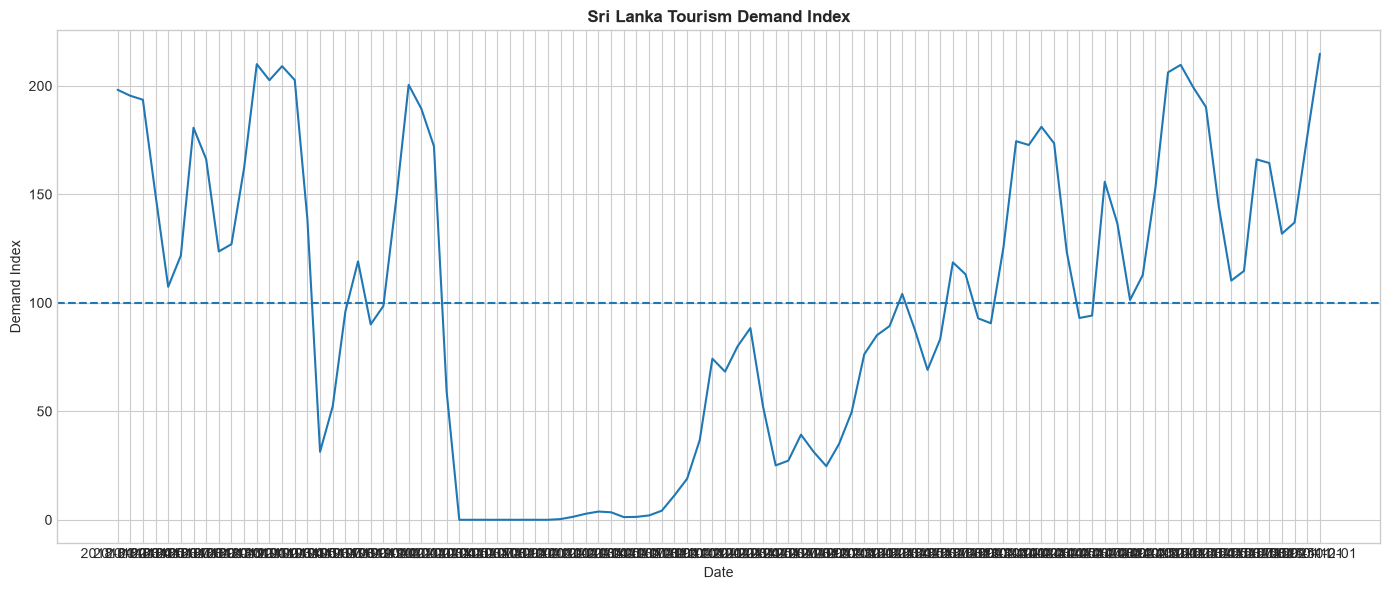

In [143]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly,
    x="Date",
    y="Demand_Index"
)

plt.axhline(
    100,
    linestyle="--"
)

plt.title(
    "Sri Lanka Tourism Demand Index"
)

plt.ylabel("Demand Index")

plt.tight_layout()
plt.show()

### Time_Series_Analysis

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .sort_index()
)

monthly.index = pd.DatetimeIndex(
    monthly.index
)

monthly.head()

Date
2018-01-01    238924.0
2018-02-01    235618.0
2018-03-01    233382.0
2018-04-01    180429.0
2018-05-01    129466.0
Name: Tourist_Arrivals, dtype: float64

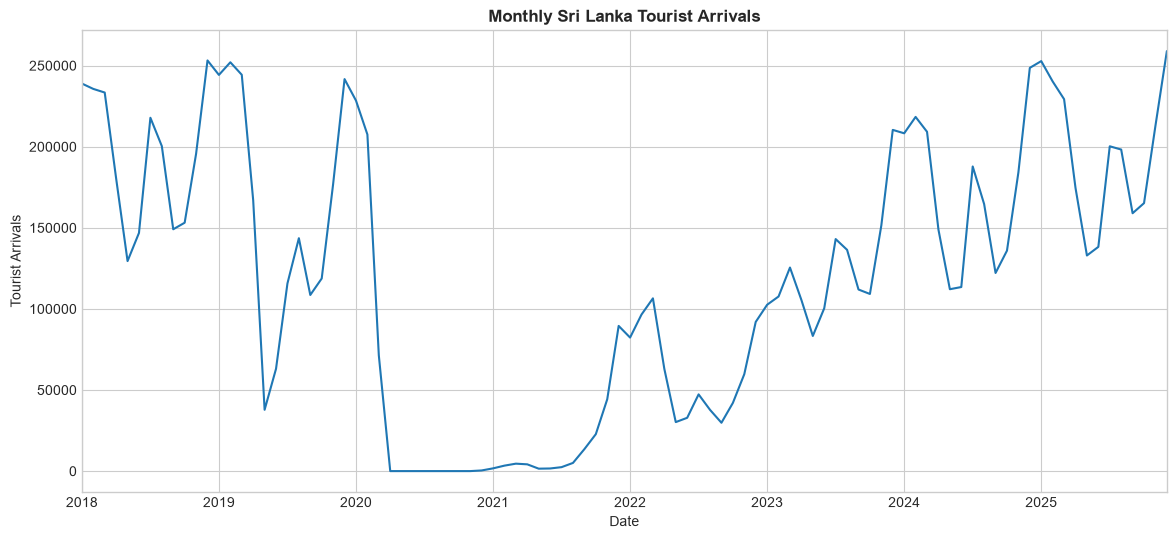

In [145]:
plt.figure(figsize=(14, 6))

monthly.plot()

plt.title(
    "Monthly Sri Lanka Tourist Arrivals"
)

plt.ylabel("Tourist Arrivals")
plt.grid(True)

plt.show()

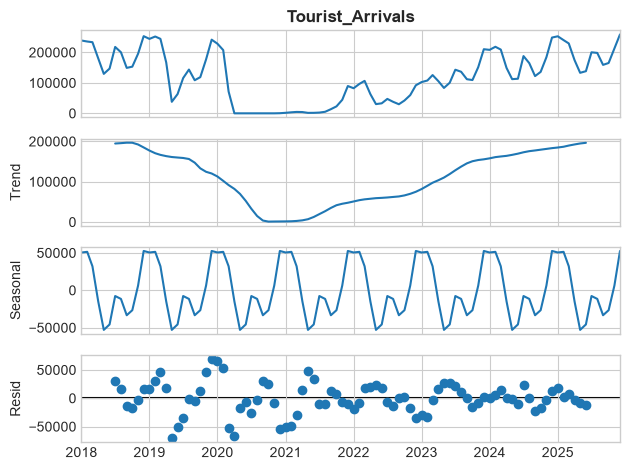

In [146]:
decomposition = seasonal_decompose(
    monthly,
    model="additive",
    period=12
)

decomposition.plot()

plt.tight_layout()
plt.show()

### Tourism_Forecasting

In [147]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [148]:
monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .sort_index()
)

monthly.index = pd.DatetimeIndex(
    monthly.index
)

monthly = monthly.asfreq("MS")

In [149]:
train = monthly.iloc[:-12]
test = monthly.iloc[-12:]

print("Training:", len(train))
print("Testing:", len(test))

Training: 84
Testing: 12


In [150]:
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(
    disp=False
)

print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                   Tourist_Arrivals   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -660.167
Date:                            Mon, 05 Oct 2026   AIC                           1330.335
Time:                                    12:54:43   BIC                           1340.550
Sample:                                01-01-2018   HQIC                          1334.305
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3405      0.397     -0.858      0.391      -1.118       0.437
ma.L1          0.6836      0.244   

In [151]:
forecast = model_fit.forecast(
    steps=len(test)
)

forecast.index = test.index

In [152]:
mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 37318.47421366914
RMSE: 39751.17906852367


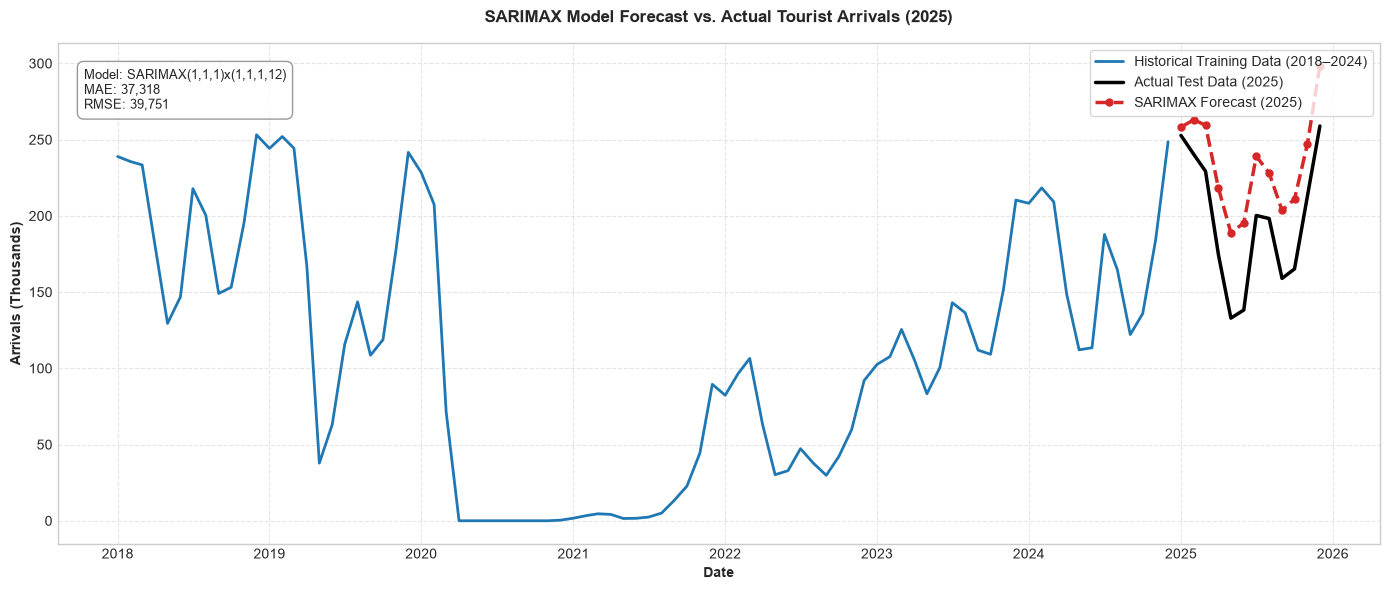

In [153]:
plt.figure(figsize=(14, 6))

plt.plot(
    train.index,
    train / 1e3,
    color="#1f77b4",
    linewidth=2,
    label="Historical Training Data (2018–2024)"
)

plt.plot(
    test.index,
    test / 1e3,
    color="black",
    linewidth=2.5,
    label="Actual Test Data (2025)"
)

plt.plot(
    forecast.index,
    forecast / 1e3,
    color="#d62728",
    linestyle="--",
    linewidth=2.5,
    marker="o",
    markersize=5,
    label="SARIMAX Forecast (2025)"
)

# Text box with evaluation metrics
metrics_text = f"Model: SARIMAX(1,1,1)x(1,1,1,12)\nMAE: {mae:,.0f}\nRMSE: {rmse:,.0f}"
plt.gca().text(
    0.02, 0.95,
    metrics_text,
    transform=plt.gca().transAxes,
    fontsize=9.5,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.title("SARIMAX Model Forecast vs. Actual Tourist Arrivals (2025)", pad=15)
plt.xlabel("Date", fontweight="bold")
plt.ylabel("Arrivals (Thousands)", fontweight="bold")
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### What_If_Scenario_Analysis

In [154]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

latest_value = yearly[
    yearly["Year"] == yearly["Year"].max()
]["Tourist_Arrivals"].iloc[0]

print(
    "Latest tourism arrivals:",
    latest_value
)

Latest tourism arrivals: 2362521.0


In [155]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

latest_value = yearly[
    yearly["Year"] == yearly["Year"].max()
]["Tourist_Arrivals"].iloc[0]

print(
    "Latest tourism arrivals:",
    latest_value
)

Latest tourism arrivals: 2362521.0


In [156]:
scenarios = pd.DataFrame({
    "Scenario": [
        "Downside",
        "Baseline",
        "Growth +10%",
        "Growth +20%"
    ],
    
    "Change_%": [
        -10,
        0,
        10,
        20
    ]
})

scenarios["Projected_Arrivals"] = (
    latest_value
    * (1 + scenarios["Change_%"] / 100)
)

scenarios

,Scenario,Change_%,Projected_Arrivals
0,Downside,-10,2126268.9
1,Baseline,0,2362521.0
2,Growth +10%,10,2598773.1
3,Growth +20%,20,2835025.2


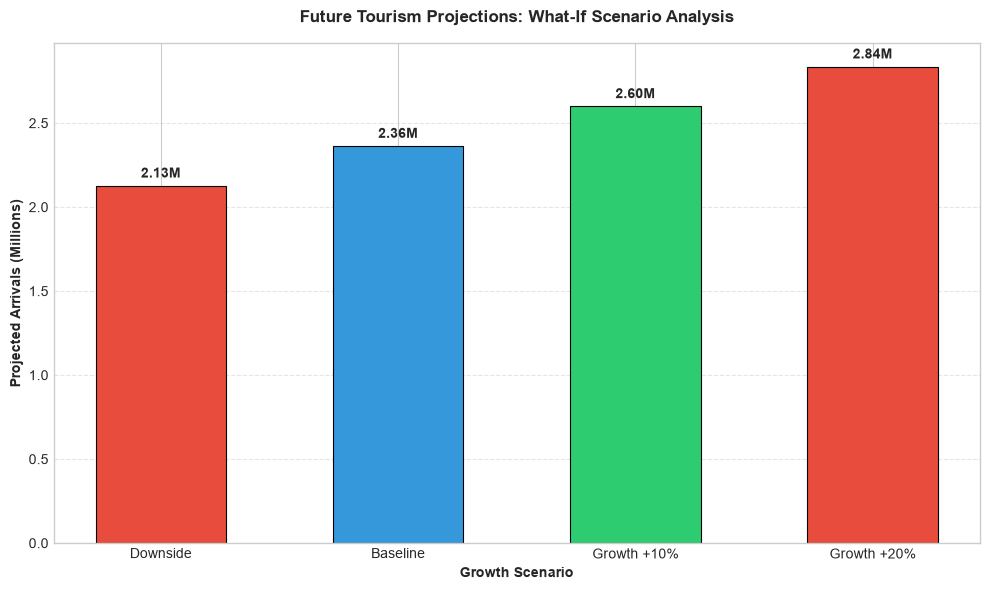

In [157]:
plt.figure(figsize=(10, 6))

scenario_colors = ["#e74c3c", "#3498db", "#2ecc71"]

bars = plt.bar(
    scenarios["Scenario"],
    scenarios["Projected_Arrivals"] / 1e6,
    color=scenario_colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.55
)

for bar in bars:
    h = bar.get_height()
    plt.annotate(
        f"{h:.2f}M",
        (bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Future Tourism Projections: What-If Scenario Analysis", pad=15)
plt.xlabel("Growth Scenario", fontweight="bold")
plt.ylabel("Projected Arrivals (Millions)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5, axis="y")

plt.tight_layout()
plt.show()

### Final_Business_Insights

In [158]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/tourism_arrivals_clean.csv"
)

In [159]:
total_arrivals = df[
    "Tourist_Arrivals"
].sum()

years = df["Year"].nunique()

countries = df["Country"].nunique()

average_monthly = (
    df.groupby("Date")["Tourist_Arrivals"]
    .sum()
    .mean()
)

print("Total Tourist Arrivals:", total_arrivals)
print("Years Covered:", years)
print("Countries Covered:", countries)
print("Average Monthly Arrivals:", average_monthly)

Total Tourist Arrivals: 11572959.0
Years Covered: 8
Countries Covered: 573
Average Monthly Arrivals: 120551.65625


In [160]:
yearly = (
    df.groupby("Year")["Tourist_Arrivals"]
    .sum()
    .reset_index()
)

highest_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmax()
]

print(
    "Highest Tourism Year:",
    highest_year["Year"]
)

print(
    "Arrivals:",
    highest_year["Tourist_Arrivals"]
)

Highest Tourism Year: 2025.0
Arrivals: 2362521.0


In [161]:
lowest_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmin()
]

print(
    "Lowest Tourism Year:",
    lowest_year["Year"]
)

print(
    "Arrivals:",
    lowest_year["Tourist_Arrivals"]
)

Lowest Tourism Year: 2021.0
Arrivals: 194495.0


In [162]:
top_country = (
    df.groupby("Country")
    ["Tourist_Arrivals"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print(top_country)

Country
India                 1374333.0
Russian Federation     677270.0
United Kingdom         605891.0
UNITED KINGDOM         525053.0
INDIA                  500627.0
Germany                442131.0
INDIA, REPUBLIC OF     424887.0
GERMANY                338736.0
China                  337220.0
Australia              297420.0
Name: Tourist_Arrivals, dtype: float64


In [163]:
best_month = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(1)
)

best_month

Month_Number  Month   
12            December    1394564.0
Name: Tourist_Arrivals, dtype: float64

In [164]:
yearly["Recovery_Index"] = (
    yearly["Tourist_Arrivals"]
    / yearly.loc[
        yearly["Year"] == 2019,
        "Tourist_Arrivals"
    ].iloc[0]
    * 100
)

yearly

,Year,Tourist_Arrivals,Recovery_Index
0,2018,2333796.0,121.951903
1,2019,1913702.0,100.000000
2,2020,507699.0,26.529679
3,2021,194495.0,10.163286
4,2022,719978.0,37.622263
5,2023,1487303.0,77.718631
6,2024,2053465.0,107.303279
7,2025,2362521.0,123.452920


In [165]:
top10 = (
    df.groupby("Country")
    ["Tourist_Arrivals"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top10

Country
India                 1374333.0
Russian Federation     677270.0
United Kingdom         605891.0
UNITED KINGDOM         525053.0
INDIA                  500627.0
Germany                442131.0
INDIA, REPUBLIC OF     424887.0
GERMANY                338736.0
China                  337220.0
Australia              297420.0
Name: Tourist_Arrivals, dtype: float64

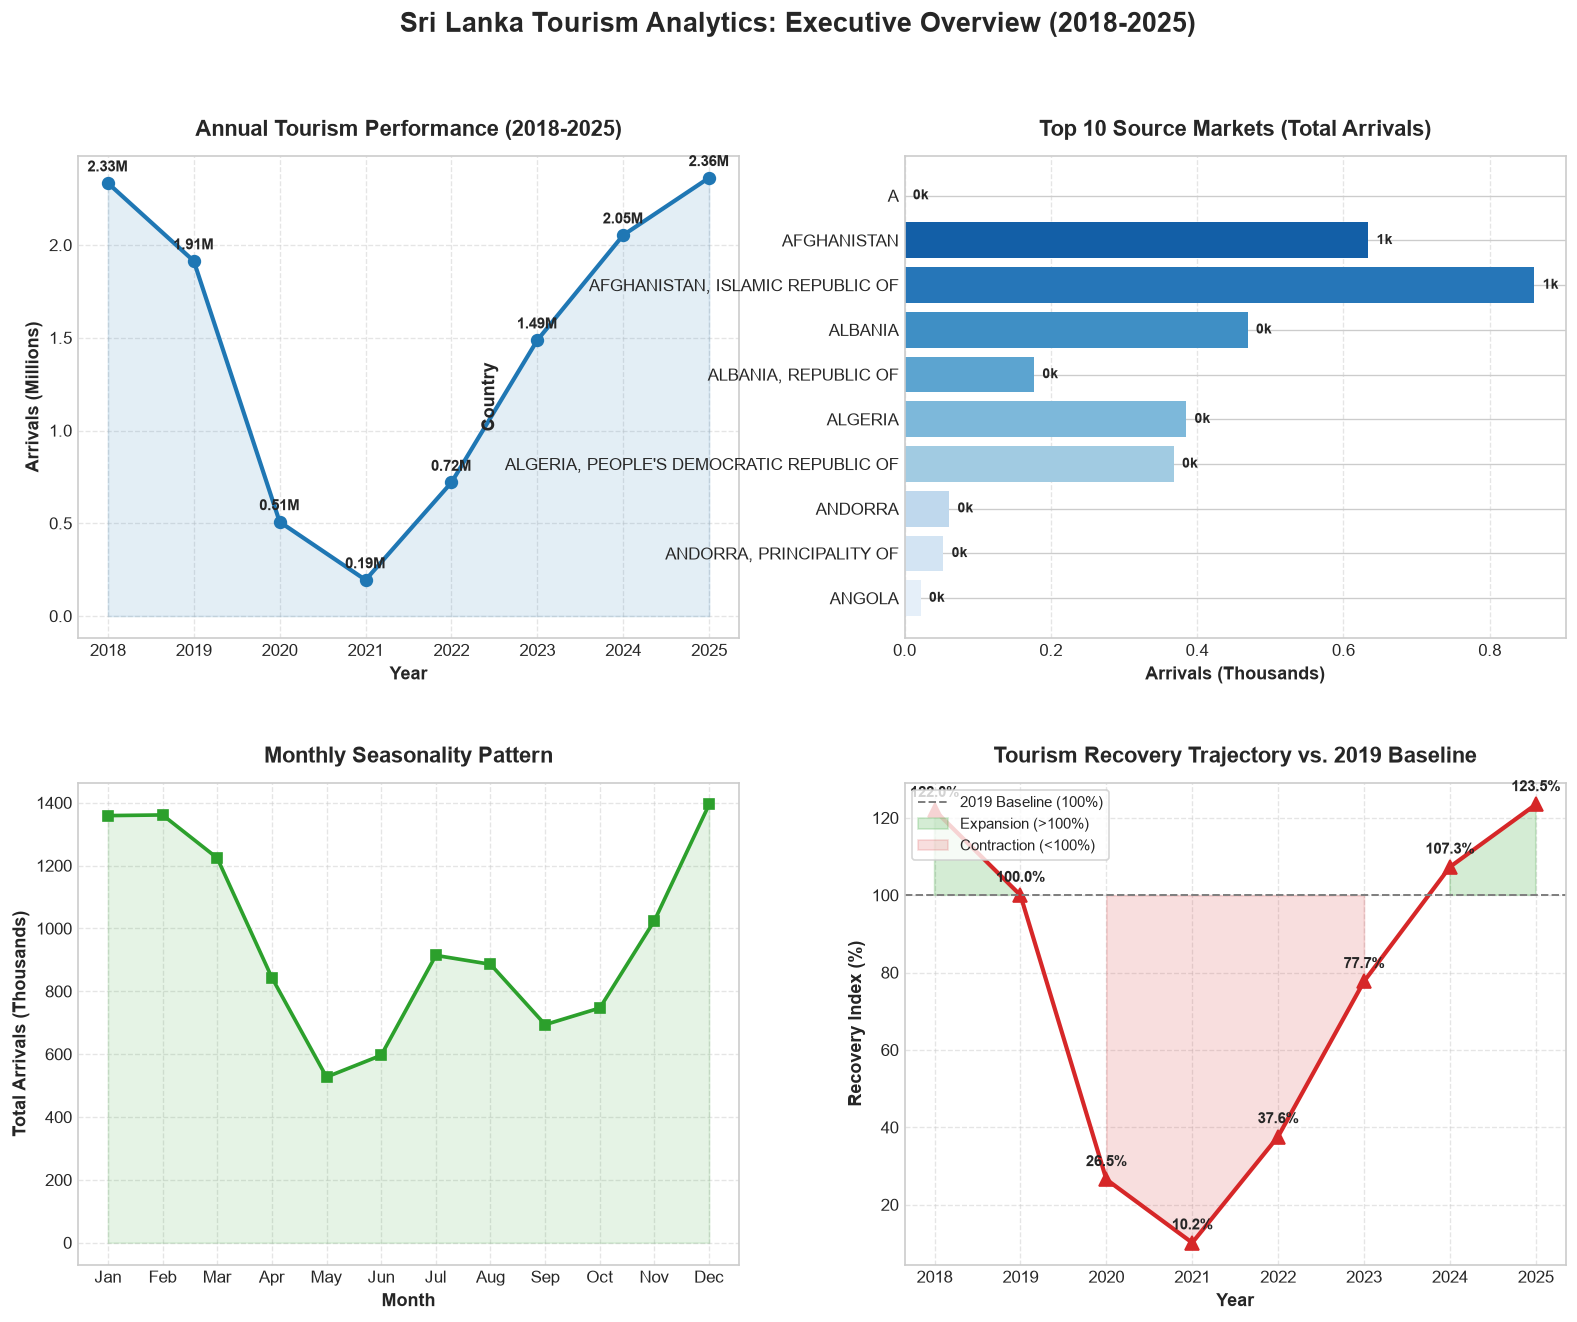

In [166]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=120)
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Panel 1: Yearly Performance
axes[0, 0].plot(yearly["Year"], yearly["Tourist_Arrivals"] / 1e6, marker="o", color="#1f77b4", linewidth=2.5, markersize=7)
axes[0, 0].fill_between(yearly["Year"], yearly["Tourist_Arrivals"] / 1e6, color="#1f77b4", alpha=0.12)
axes[0, 0].set_title("Annual Tourism Performance (2018-2025)", fontsize=13, fontweight="bold", pad=12)
axes[0, 0].set_ylabel("Arrivals (Millions)", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Year", fontsize=11, fontweight="bold")
axes[0, 0].grid(True, linestyle="--", alpha=0.5)
for _, r in yearly.iterrows():
    axes[0, 0].annotate(f"{r['Tourist_Arrivals']/1e6:.2f}M", (r["Year"], r["Tourist_Arrivals"] / 1e6),
                        xytext=(0, 7), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

# Panel 2: Top 10 Source Markets
top10_clean = country.head(10).copy()
colors = sns.color_palette("Blues_r", 10)
bars = axes[0, 1].barh(top10_clean["Country"][::-1], top10_clean["Tourist_Arrivals"][::-1] / 1e3, color=colors[::-1], edgecolor="none")
axes[0, 1].set_title("Top 10 Source Markets (Total Arrivals)", fontsize=13, fontweight="bold", pad=12)
axes[0, 1].set_xlabel("Arrivals (Thousands)", fontsize=11, fontweight="bold")
axes[0, 1].set_ylabel("Country", fontsize=11, fontweight="bold")
axes[0, 1].grid(True, linestyle="--", alpha=0.5, axis="x")
for bar in bars:
    w = bar.get_width()
    axes[0, 1].annotate(f"{w:,.0f}k", (w, bar.get_y() + bar.get_height() / 2),
                        xytext=(5, 0), textcoords="offset points", va="center", fontsize=8.5, fontweight="bold")

# Panel 3: Monthly Seasonality
monthly_season = (
    df.groupby(["Month_Number", "Month"])["Tourist_Arrivals"]
    .sum()
    .reset_index()
    .sort_values("Month_Number")
)
month_abbr = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
axes[1, 0].plot(range(1, 13), monthly_season["Tourist_Arrivals"] / 1e3, marker="s", color="#2ca02c", linewidth=2.2, markersize=6)
axes[1, 0].fill_between(range(1, 13), monthly_season["Tourist_Arrivals"] / 1e3, color="#2ca02c", alpha=0.12)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_abbr, rotation=0, fontsize=10)
axes[1, 0].set_title("Monthly Seasonality Pattern", fontsize=13, fontweight="bold", pad=12)
axes[1, 0].set_ylabel("Total Arrivals (Thousands)", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("Month", fontsize=11, fontweight="bold")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# Panel 4: Recovery Index
axes[1, 1].plot(yearly["Year"], yearly["Recovery_Index"], marker="^", color="#d62728", linewidth=2.5, markersize=8)
axes[1, 1].axhline(100, color="gray", linestyle="--", linewidth=1.2, label="2019 Baseline (100%)")
axes[1, 1].fill_between(yearly["Year"], 100, yearly["Recovery_Index"], where=(yearly["Recovery_Index"] >= 100),
                        color="#2ca02c", alpha=0.2, label="Expansion (>100%)")
axes[1, 1].fill_between(yearly["Year"], 100, yearly["Recovery_Index"], where=(yearly["Recovery_Index"] < 100),
                        color="#d62728", alpha=0.15, label="Contraction (<100%)")
axes[1, 1].set_title("Tourism Recovery Trajectory vs. 2019 Baseline", fontsize=13, fontweight="bold", pad=12)
axes[1, 1].set_ylabel("Recovery Index (%)", fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("Year", fontsize=11, fontweight="bold")
axes[1, 1].legend(loc="upper left", frameon=True, fontsize=9)
axes[1, 1].grid(True, linestyle="--", alpha=0.5)
for _, r in yearly.iterrows():
    axes[1, 1].annotate(f"{r['Recovery_Index']:.1f}%", (r["Year"], r["Recovery_Index"]),
                        xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Sri Lanka Tourism Analytics: Executive Overview (2018-2025)", fontsize=16, fontweight="bold", y=0.98)
os.makedirs("../outputs/figures", exist_ok=True)
plt.savefig("../outputs/figures/final_tourism_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [167]:
insights = []

# Highest year
best_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmax()
]

insights.append({
    "Insight": "Highest Tourism Year",
    "Value": best_year["Year"],
    "Metric": best_year["Tourist_Arrivals"]
})

# Lowest year
worst_year = yearly.loc[
    yearly["Tourist_Arrivals"].idxmin()
]

insights.append({
    "Insight": "Lowest Tourism Year",
    "Value": worst_year["Year"],
    "Metric": worst_year["Tourist_Arrivals"]
})

# Top country
best_country = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .idxmax()
)

best_country_value = (
    df.groupby("Country")["Tourist_Arrivals"]
    .sum()
    .max()
)

insights.append({
    "Insight": "Largest Source Market",
    "Value": best_country,
    "Metric": best_country_value
})

# Best month
best_month_row = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .idxmax()
)

best_month_value = (
    df.groupby(
        ["Month_Number", "Month"]
    )["Tourist_Arrivals"]
    .sum()
    .max()
)

insights.append({
    "Insight": "Highest Tourism Month",
    "Value": best_month_row[1],
    "Metric": best_month_value
})

insights_df = pd.DataFrame(insights)

insights_df

,Insight,Value,Metric
0,Highest Tourism Year,2025.0,2362521.0
1,Lowest Tourism Year,2021.0,194495.0
2,Largest Source Market,India,1374333.0
3,Highest Tourism Month,December,1394564.0


In [168]:
import os

os.makedirs("../outputs/tables", exist_ok=True)

insights_df.to_csv(
    "../outputs/tables/final_business_insights.csv",
    index=False
)

print(
    "Final business insights saved."
)

Final business insights saved.
